In [1]:
from DatabankLib.protein_functions import *
import yaml

databankPath = "/home/sosamuli/work/NMRlipids/IDPdatabank/"  # this is the local path for the cloned Databank
os.environ["NMLDB_ROOT_PATH"] = "/home/sosamuli/work/NMRlipids/IDPdatabank/"

#databankPath = "/home/sosamuli/work/NMRlipids/IDPsimBank/"  # this is the local path for the cloned Databank
#os.environ["NMLDB_ROOT_PATH"] = "/home/sosamuli/work/NMRlipids/IDPsimBank/"


# These two lines include core Databank routines and Databank API
from DatabankLib.core import *
from DatabankLib.databankLibrary import *
# This is for plotting
from DatabankLib.databankio import *
from DatabankLib.plottings import plotSimulation
#from IPython.display import display, Markdown

# This initializes the databank and stores the information of all simulations into a list.
# Each list item contains the information from README.yaml file of the given simulation.
systems = initialize_databank()

/home/sosamuli/anaconda3/envs/IDPdatabank/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/sosamuli/anaconda3/envs/IDPdatabank/lib/python3.11/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


Databank initialized from the folder: /home/sosamuli/work/NMRlipids/IDPdatabank/Data/Simulations


🧩 Generating relaxation heatmap: ../../Data/Simulations/7ba/91f/7ba91f0ff97f2a73cae20f5eec60e1c9040aaed6/4679d7713aabbcab3b480e0d63ed1e645aef0495/spin_relaxation_quality_heatmap.png
✅ Relaxation heatmap saved successfully.
[['KRS1-72_replica_03_CHARMM36M_2000ns.xtc']] 138 []
🧩 Generating heatmap: ../../Data/Simulations/7ba/91f/7ba91f0ff97f2a73cae20f5eec60e1c9040aaed6/4679d7713aabbcab3b480e0d63ed1e645aef0495/chemical_shift_quality_heatmap.png
✅ Heatmap saved successfully.
🧩 Generating relaxation heatmap: ../../Data/Simulations/7ba/bf0/7babf08d76a410719cdfac0b58fabcd010cb2e8f/fb43125cd3952f71f14aa490fb97d0e24292106e/spin_relaxation_quality_heatmap.png
✅ Relaxation heatmap saved successfully.
[['aSyn_replica_04_CHARMM36M_2000ns.xtc']] 103 [670.0, 670.0, 670.0, 670.0, 670.0]
🧩 Generating heatmap: ../../Data/Simulations/7ba/bf0/7babf08d76a410719cdfac0b58fabcd010cb2e8f/fb43125cd3952f71f14aa490fb97d0e24292106e/chemical_shift_quality_heatmap.png
✅ Heatmap saved successfully.
🧩 Generating relax

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7f8155dcb4c0> (for post_execute), with arguments args (),kwargs {}:


KeyboardInterrupt: 

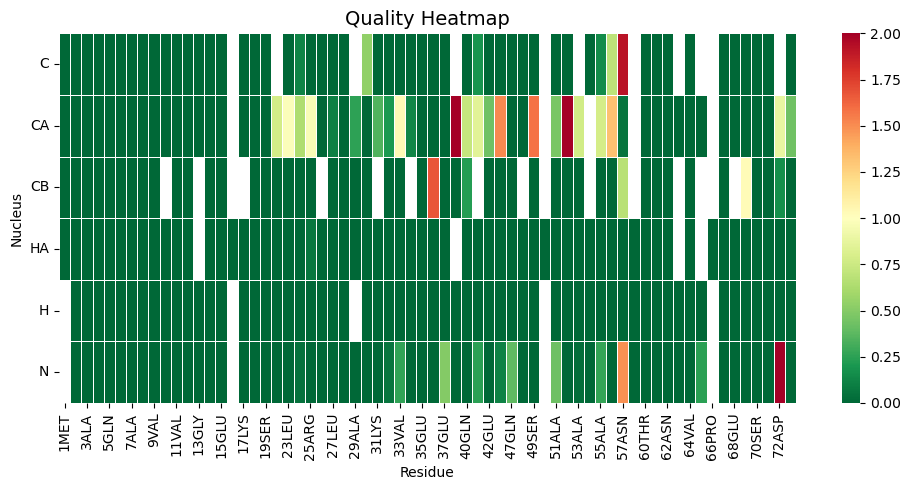

In [4]:
relaxation_accuracies = {
        "R1": 0.18,
        "R2": 3.8,
        "hetNOE": 0.1
    }
    
#From SPARTA+ article
atom_accuracies = {
        'C': 1.5,
        'CA': 1.0,
        'CB': 1.3,
        'H': 0.55,
        'HA': 0.3,
        'N': 2.5
    }

for system in systems:
    evaluate_spin_relaxation_quality(system, relaxation_accuracies)
    evaluate_chemical_shift_quality(system, atom_accuracies)

In [ ]:
for system in systems:
    if 'KRS' not in system['SYSTEM']:
        continue
    print(system['SYSTEM'], system['TRJ'])
    dataFolder = '../../Data/Simulations/' + system['path']
    # Paths
    chem_path = dataFolder + 'chemical_shift_quality_heatmap.png'
    relax_path = dataFolder + 'spin_relaxation_quality_heatmap.png'

    # Load images
    img1 = plt.imread(chem_path)move the color bar only to a one color bar at the right hand side of the figure, and have residue numbers only on bottom and left hand side panels?
    img2 = plt.imread(relax_path)

    # Create side-by-side plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Chemical shift heatmap
    axes[0].imshow(img1)
    axes[0].set_title("Chemical Shift Quality", fontsize=14)
    axes[0].axis("off")

    # Relaxation heatmap
    axes[1].imshow(img2)
    axes[1].set_title("Relaxation Quality", fontsize=14)
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()



In [ ]:
import re
import matplotlib.pyplot as plt
import numpy as np

# --- First pass: organize systems into a structure {replica: {forcefield: system}} ---
grid = {}

for system in systems:
    if 'KRS' not in system['SYSTEM']:
        continue

    trj = system['TRJ'][0][0]

    # Example: KRS1-72_replica_05_AMBER03WS_2000ns.xtc
    match = re.search(r"replica_(\d+)_([A-Za-z0-9]+)_", trj)
    if not match:
        print("Could not parse:", trj)
        continue

    replica = match.group(1)
    forcefield = match.group(2)

    if replica not in grid:
        grid[replica] = {}
    grid[replica][forcefield] = system


# --- Determine sorted order of replicas and forcefields ---
replicas = sorted(grid.keys(), key=lambda x: int(x))
forcefields = sorted(
    {ff for rep in grid.values() for ff in rep.keys()}
)

n_rows = len(replicas)
n_cols = len(forcefields) * 2   # because each system has 2 images (chem + relax)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))

if n_rows == 1:
    axes = np.expand_dims(axes, axis=0)

# --- Fill the grid ---
for r_idx, replica in enumerate(replicas):
    for c_idx, forcefield in enumerate(forcefields):

        ax_chem = axes[r_idx, 2*c_idx]
        ax_relax = axes[r_idx, 2*c_idx + 1]

        if forcefield not in grid[replica]:
            ax_chem.axis("off")
            ax_relax.axis("off")
            continue

        system = grid[replica][forcefield]
        dataFolder = '../../Data/Simulations/' + system['path']

        # Load heatmaps
        chem_path = dataFolder + 'chemical_shift_quality_heatmap.png'
        relax_path = dataFolder + 'spin_relaxation_quality_heatmap.png'

        img_chem = plt.imread(chem_path)
        img_relax = plt.imread(relax_path)

        # Plot chemical shift
        ax_chem.imshow(img_chem)
        ax_chem.axis("off")
        if r_idx == 0:
            ax_chem.set_title(f"{forcefield}\nChemical Shift", fontsize=12)

        # Plot relaxation
        ax_relax.imshow(img_relax)
        ax_relax.axis("off")
        if r_idx == 0:
            ax_relax.set_title(f"{forcefield}\nRelaxation", fontsize=12)

    # Row label = replica number
    axes[r_idx, 0].set_ylabel(f"Replica {replica}", fontsize=14)

plt.tight_layout()
plt.show()


In [ ]:
import re
import matplotlib.pyplot as plt
import numpy as np
import os

# --- First pass: organize systems into a structure {replica: {forcefield: system}} ---
grid = {}

for system in systems:
    if 'KRS' not in system['SYSTEM']:
        continue

    trj = system['TRJ'][0][0]

    # Extract replica and force field
    match = re.search(r"replica_(\d+)_([A-Za-z0-9]+)_", trj)
    if not match:
        print("Could not parse:", trj)
        continue

    replica = match.group(1)
    forcefield = match.group(2)

    grid.setdefault(replica, {})
    grid[replica][forcefield] = system

# Sort ordering
replicas = sorted(grid.keys(), key=lambda x: int(x))
forcefields = sorted({ff for rep in grid.values() for ff in rep.keys()})

n_rows = len(replicas)
n_cols = len(forcefields)

# A helper function to build a figure for a given heatmap type
def plot_heatmap_grid(type_name, filename):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))

    # Normalize axes shape
    if n_rows == 1:
        axes = np.expand_dims(axes, 0)
    if n_cols == 1:
        axes = np.expand_dims(axes, 1)

    for r_idx, replica in enumerate(replicas):
        for c_idx, forcefield in enumerate(forcefields):

            ax = axes[r_idx, c_idx]

            if forcefield not in grid[replica]:
                ax.axis("off")
                continue

            system = grid[replica][forcefield]
            dataFolder = '../../Data/Simulations/' + system['path']

            img_path = os.path.join(dataFolder, filename)
            img = plt.imread(img_path)

            ax.imshow(img)
            ax.axis("off")

            # Set column header on first row
            if r_idx == 0:
                ax.set_title(forcefield, fontsize=13)

        # Row label on the leftmost subplot
        axes[r_idx, 0].set_ylabel(f"Replica {replica}", fontsize=14)

    plt.suptitle(type_name, fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()


# --- Plot 1: Chemical shift grid ---
plot_heatmap_grid(
    type_name="Chemical Shift Quality",
    filename="chemical_shift_quality_heatmap.png"
)

# --- Plot 2: Relaxation grid ---
plot_heatmap_grid(
    type_name="Spin Relaxation Quality",
    filename="spin_relaxation_quality_heatmap.png"
)


In [49]:
import numpy as np

def compute_rmsd_between_files(file1, file2):
    """
    Compute RMSD between the second-column values of two text files,
    aligning by the first-column index (e.g., residue/frame number).

    Works even if files have missing rows or different formats.
    """

    def load_index_value_map(filename):
        data = {}
        with open(filename) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 2:
                    continue
                try:
                    idx = int(float(parts[0]))
                    val = float(parts[1])
                    if np.isfinite(val):
                        data[idx] = val
                except ValueError:
                    continue
        return data

    data1 = load_index_value_map(file1)
    data2 = load_index_value_map(file2)

    # Find common indices
    common_indices = sorted(set(data1.keys()) & set(data2.keys()))
    if not common_indices:
        print("⚠️ No overlapping indices found between files.")
        return None

    vals1 = np.array([data1[i] for i in common_indices])
    vals2 = np.array([data2[i] for i in common_indices])

    rmsd = np.sqrt(np.mean((vals1 - vals2) ** 2))

    print(f"✅ Compared {len(common_indices)} common indices.")
    return rmsd


In [47]:
file1 = '/home/sosamuli/Dropbox/TonB/Data/T2fromSmulationsTIP4P_T303K.dat'
file2 = '/home/sosamuli/Dropbox/TonB/Data/experimentalRELAXATIONdata/T2experimentalDATA850MHz.dat'
compute_rmsd_between_files(file1, file2)

✅ Compared 79 common indices.


3.8338524741206323

In [50]:
file1 = '/home/sosamuli/Dropbox/TonB/Data/NOEfromSmulationsTIP4P_303K.dat'
file2 = '/home/sosamuli/Dropbox/TonB/Data/experimentalRELAXATIONdata/15N-NOEexperimentalDATA850MHz.dat'
compute_rmsd_between_files(file1, file2)

✅ Compared 84 common indices.


0.10612276830024654

In [38]:
import os
import re
import matplotlib.pyplot as plt

# Fixed order of force fields
FF_ORDER = ["AMBER03WS", "AMBER99SB-DISP", "AMBER99SBWS", "DESAMBER", "CHARMM36M"]

def extract_ff_and_replica(trj_name):
    """Extract force field and replica number from trajectory filename."""
    match_ff = re.search(r"(AMBER03WS|AMBER99SB-DISP|AMBER99SBWS|DESAMBER|CHARMM36M)", trj_name.upper())
    match_rep = re.search(r"replica_(\d+)", trj_name)
    ff = match_ff.group(1) if match_ff else "UNKNOWN"
    replica = int(match_rep.group(1)) if match_rep else 0
    return ff, replica


def plot_heatmaps(systems, plot_type="chemical_shift", save_path=None):
    """
    Create a heatmap grid for either chemical shifts or relaxation data.

    Parameters
    ----------
    systems : list of dict
        Simulation system metadata.
    plot_type : str
        Either "chemical_shift" or "relaxation".
    save_path : str or None
        If provided, saves the figure instead of displaying it.
    """
    assert plot_type in ["chemical_shift", "relaxation"], "Invalid plot type"

    # --- Organize systems by force field and replica ---
    systems_by_ff = {ff: {} for ff in FF_ORDER}
    for system in systems:
        if 'asyn' not in system.get('SYSTEM', ''):
            continue
        trj_name = system['TRJ'][0][0]
        ff, replica = extract_ff_and_replica(trj_name)
        if ff in systems_by_ff:
            systems_by_ff[ff][replica] = system

    # --- Determine layout ---
    all_replicas = sorted({rep for ff_data in systems_by_ff.values() for rep in ff_data.keys()})
    n_rows = len(all_replicas)
    n_cols = len(FF_ORDER)

    # --- Create figure ---
    fig, axes = plt.subplots(
        nrows=n_rows,
        ncols=n_cols,
        figsize=(4 * n_cols, 2.5 * n_rows),
    )

    if n_rows == 1:
        axes = [axes]  # handle single-row case

    for col, ff in enumerate(FF_ORDER):
        for row_idx, replica in enumerate(all_replicas):
            ax = axes[row_idx][col]
            ax.axis("off")

            system = systems_by_ff[ff].get(replica)
            if system:
                dataFolder = os.path.join('../../Data/Simulations', system['path'])
                filename = f"{plot_type}_quality_heatmap.png"
                path = os.path.join(dataFolder, filename)
                if os.path.exists(path):
                    img = plt.imread(path)
                    ax.imshow(img)

            # Titles and labels
            if row_idx == 0:
                ax.set_title(ff, fontsize=12, pad=10)
            if col == 0:
                ax.set_ylabel(f"Replica {replica}", fontsize=10, rotation=0, labelpad=35, va='center')

    # --- Figure title ---
    fig.suptitle(
        "Chemical Shift Quality Heatmaps" if plot_type == "chemical_shift"
        else "Spin Relaxation Quality Heatmaps",
        fontsize=16,
        y=1.02
    )

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.close(fig)
    else:
        plt.show()


# Example usage:
# plot_heatmaps(systems, plot_type="chemical_shift", save_path="chemical_shift_grid.png")
# plot_heatmaps(systems, plot_type="relaxation", save_path="relaxation_grid.png")


In [39]:
plot_heatmaps(systems, plot_type="chemical_shift", save_path="chemical_shift_grid.png")
plot_heatmaps(systems, plot_type="relaxation", save_path="relaxation_grid.png")

In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

def residue_sort_key(label):
    m = re.match(r"(\d+)", str(label))
    if m:
        return int(m.group(1))
    return float("inf")

def plot_heatmap_grid_from_csv(
    grid,
    replicas,
    forcefields,
    filename,
    title
):
    matrices = {}
    all_values = []

    # ---- First pass: load and gather all values for global color scale ---
    for rep in replicas:
        for ff in forcefields:
            folder = grid[(rep, ff)]
            csvpath = os.path.join(folder, filename)

            df = pd.read_csv(csvpath, index_col=0)
            matrices[(rep, ff)] = df
            all_values.append(df.values)

    vmin = np.min(all_values)
    vmax = np.max(all_values)

    # ---- Create figure ----
    n_rows = len(replicas)
    n_cols = len(forcefields)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(3*n_cols, 2.5*n_rows),
        constrained_layout=False
    )

    if n_rows == 1:
        axes = np.array([axes])
    if n_cols == 1:
        axes = axes[:, None]

    # ---- Plot each heatmap ----
    for i, rep in enumerate(replicas):
        for j, ff in enumerate(forcefields):

            ax = axes[i, j]
            df = matrices[(rep, ff)]

            sns.heatmap(
                df,
                ax=ax,
                cmap="RdYlGn_r",
                vmin=vmin,
                vmax=vmax,
                cbar=False,   # only add once later
                linewidths=0,
            )

            # Titles (only on top row)
            if i == 0:
                ax.set_title(ff, fontsize=12)

            # Left labels (only left column)
            if j == 0:
                ax.set_ylabel(rep, fontsize=12)
            else:
                ax.set_ylabel("")

            # Bottom labels (only bottom row)
            if i == n_rows - 1:
                ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
            else:
                ax.set_xticks([])
                ax.set_xticklabels([])

            # Y-tick labels only on left column
            if j == 0:
                ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
            else:
                ax.set_yticks([])
                ax.set_yticklabels([])

    # ---- Single shared colorbar ----
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    sm = plt.cm.ScalarMappable(norm=norm, cmap="RdYlGn_r")
    fig.colorbar(sm, cax=cbar_ax)

    fig.suptitle(title, fontsize=14, y=0.98)

    # Tight cropping like your original PNG
    plt.subplots_adjust(
        left=0.05, right=0.9,
        top=0.92, bottom=0.1,
        wspace=0.05, hspace=0.05
    )

    plt.show()

In [47]:
# Organize systems into: grid[replica][forcefield] = system
grid = {}

for system in systems:
    if 'KRS' not in system['SYSTEM']:
        continue

    trj = system['TRJ'][0][0]

    # Example: KRS1-72_replica_05_AMBER03WS_2000ns.xtc
    match = re.search(r"replica_(\d+)_([A-Za-z0-9]+)_", trj)
    if not match:
        continue

    replica = match.group(1)
    forcefield = match.group(2)

    grid.setdefault(replica, {})
    grid[replica][forcefield] = system

replicas = sorted(grid.keys(), key=lambda x: int(x))
forcefields = sorted({ff for rep in grid.values() for ff in rep})


In [49]:
def residue_sort_key(label):
    m = re.match(r"(\d+)", str(label))
    if m:
        return int(m.group(1))
    return float("inf")


def plot_heatmap_grid_from_csv(grid, replicas, forcefields, filename, title):
    n_rows = len(replicas)
    n_cols = len(forcefields)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(3.5*n_cols, 3.5*n_rows),
        sharex=True, sharey=True
    )

    # First pass: read all matrices to build union of indices/columns
    matrices = {}
    all_x = set()
    all_y = set()

    for rep in replicas:
        for ff in forcefields:
            if ff not in grid[rep]:
                continue

            path = os.path.join('../../Data/Simulations/', grid[rep][ff]['path'], filename)
            df = pd.read_csv(path, index_col=0)

            matrices[(rep, ff)] = df

            all_x.update(df.columns)
            all_y.update(df.index)

    # convert to sorted lists using numeric residue keys
    all_x = sorted(all_x, key=residue_sort_key)
    all_y = sorted(all_y, key=residue_sort_key)

    # Second pass: reindex to union axis
    reindexed = {}
    for key, df in matrices.items():
        df2 = df.reindex(index=all_y, columns=all_x)
        reindexed[key] = df2

    # Determine global vmin/vmax ignoring NaNs
    all_values = np.concatenate([df.values.flatten() for df in reindexed.values()])
    vmin = np.nanmin(all_values)
    vmax = np.nanmax(all_values)

    # Third pass: plot
    for r_idx, rep in enumerate(replicas):
        for c_idx, ff in enumerate(forcefields):

            ax = axes[r_idx, c_idx]

            if ff not in grid[rep]:
                ax.axis("off")
                continue

            df = reindexed[(rep, ff)]

            sns.heatmap(
                df,
                ax=ax,
                cmap="RdYlGn_r",
                cbar=False,               # shared colorbar handled outside
                vmin=vmin,
                vmax=vmax,
                xticklabels=(r_idx == n_rows - 1),   # bottom only
                yticklabels=(c_idx == 0),           # left only
            )

            if r_idx == 0:
                ax.set_title(ff, fontsize=12)
            if c_idx == 0:
                ax.set_ylabel(f"Replica {rep}", fontsize=12)

    # Shared colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    sm = plt.cm.ScalarMappable(cmap="RdYlGn_r", norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm.set_array([])
    fig.colorbar(sm, cax=cbar_ax)

    fig.suptitle(title, fontsize=16)
    fig.tight_layout(rect=[0, 0, 0.9, 0.95])
    plt.show()


This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


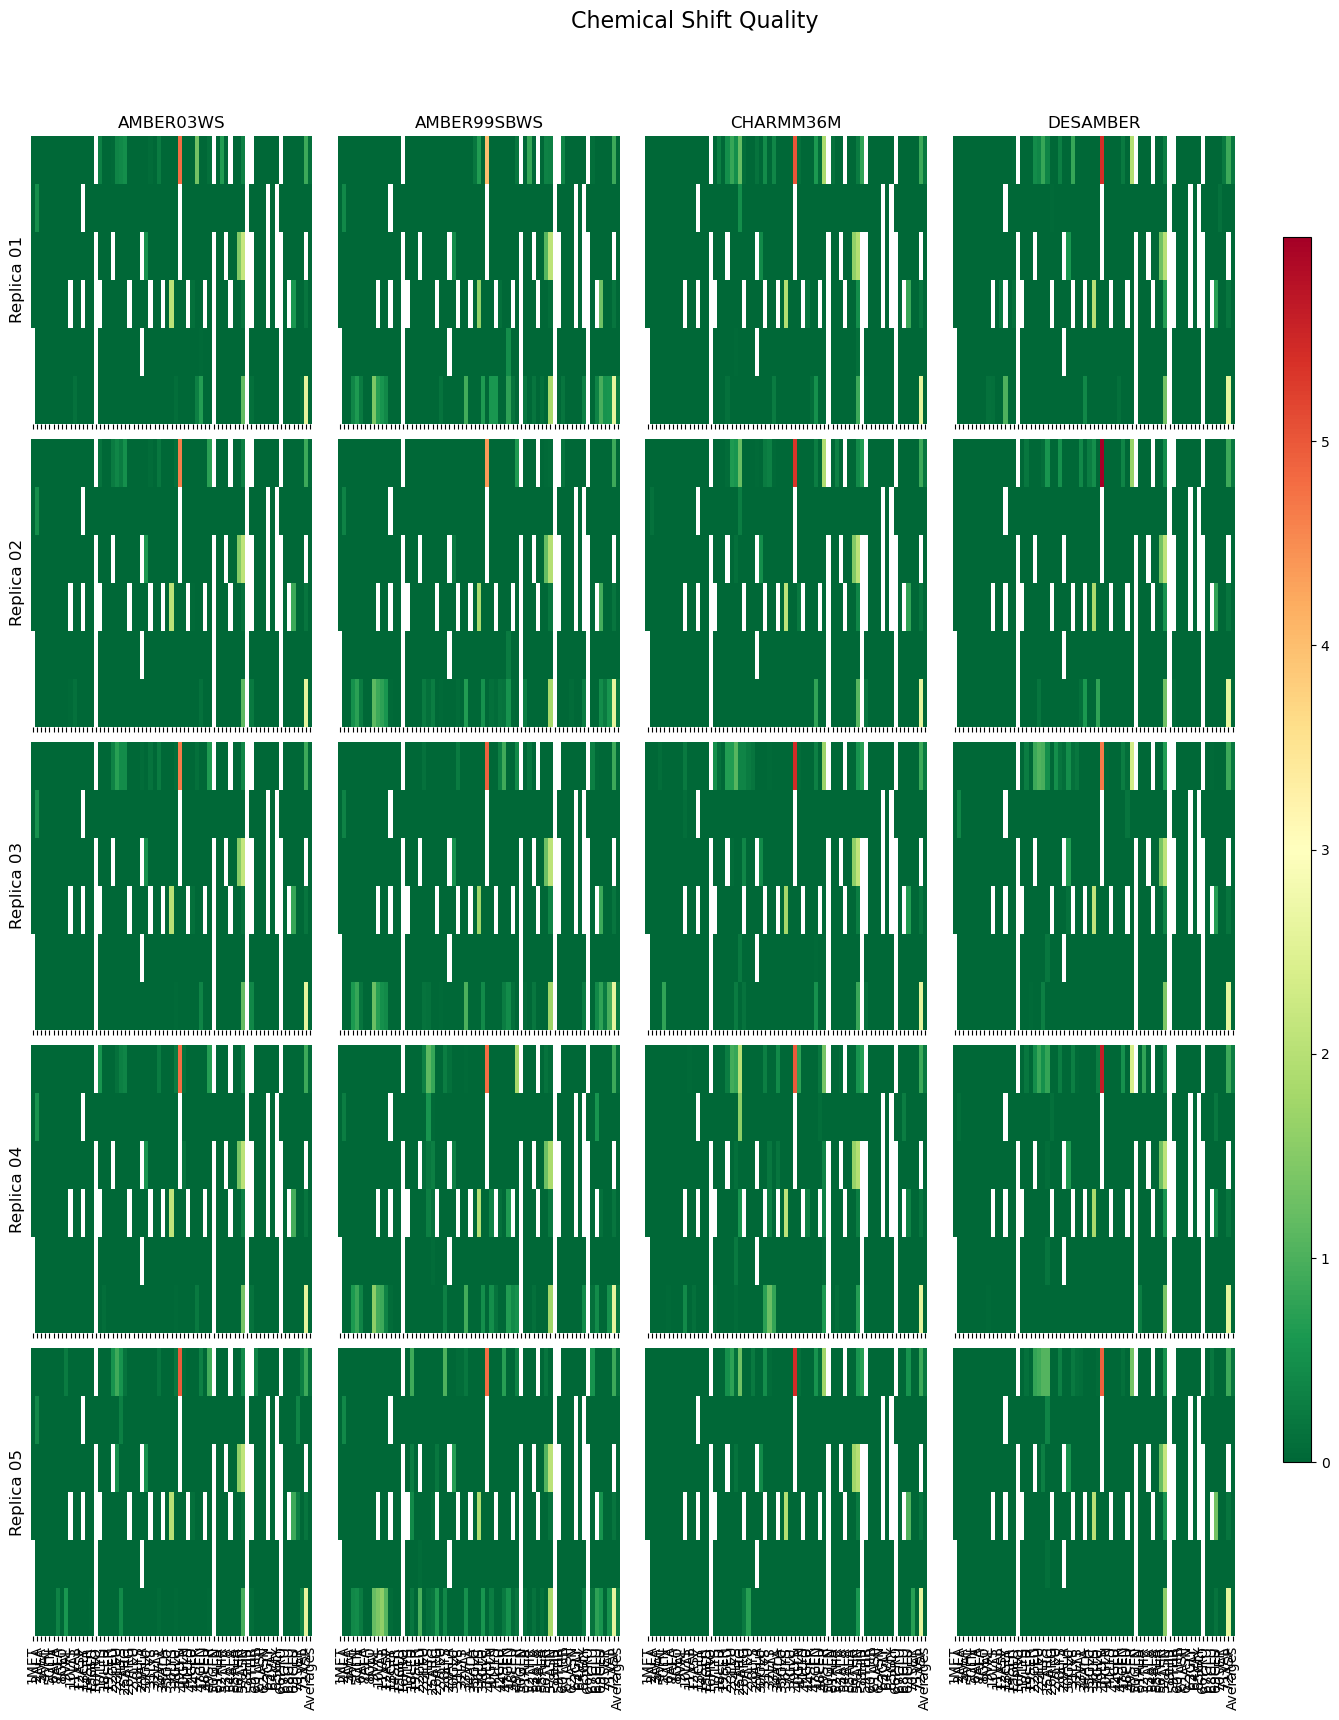

This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.


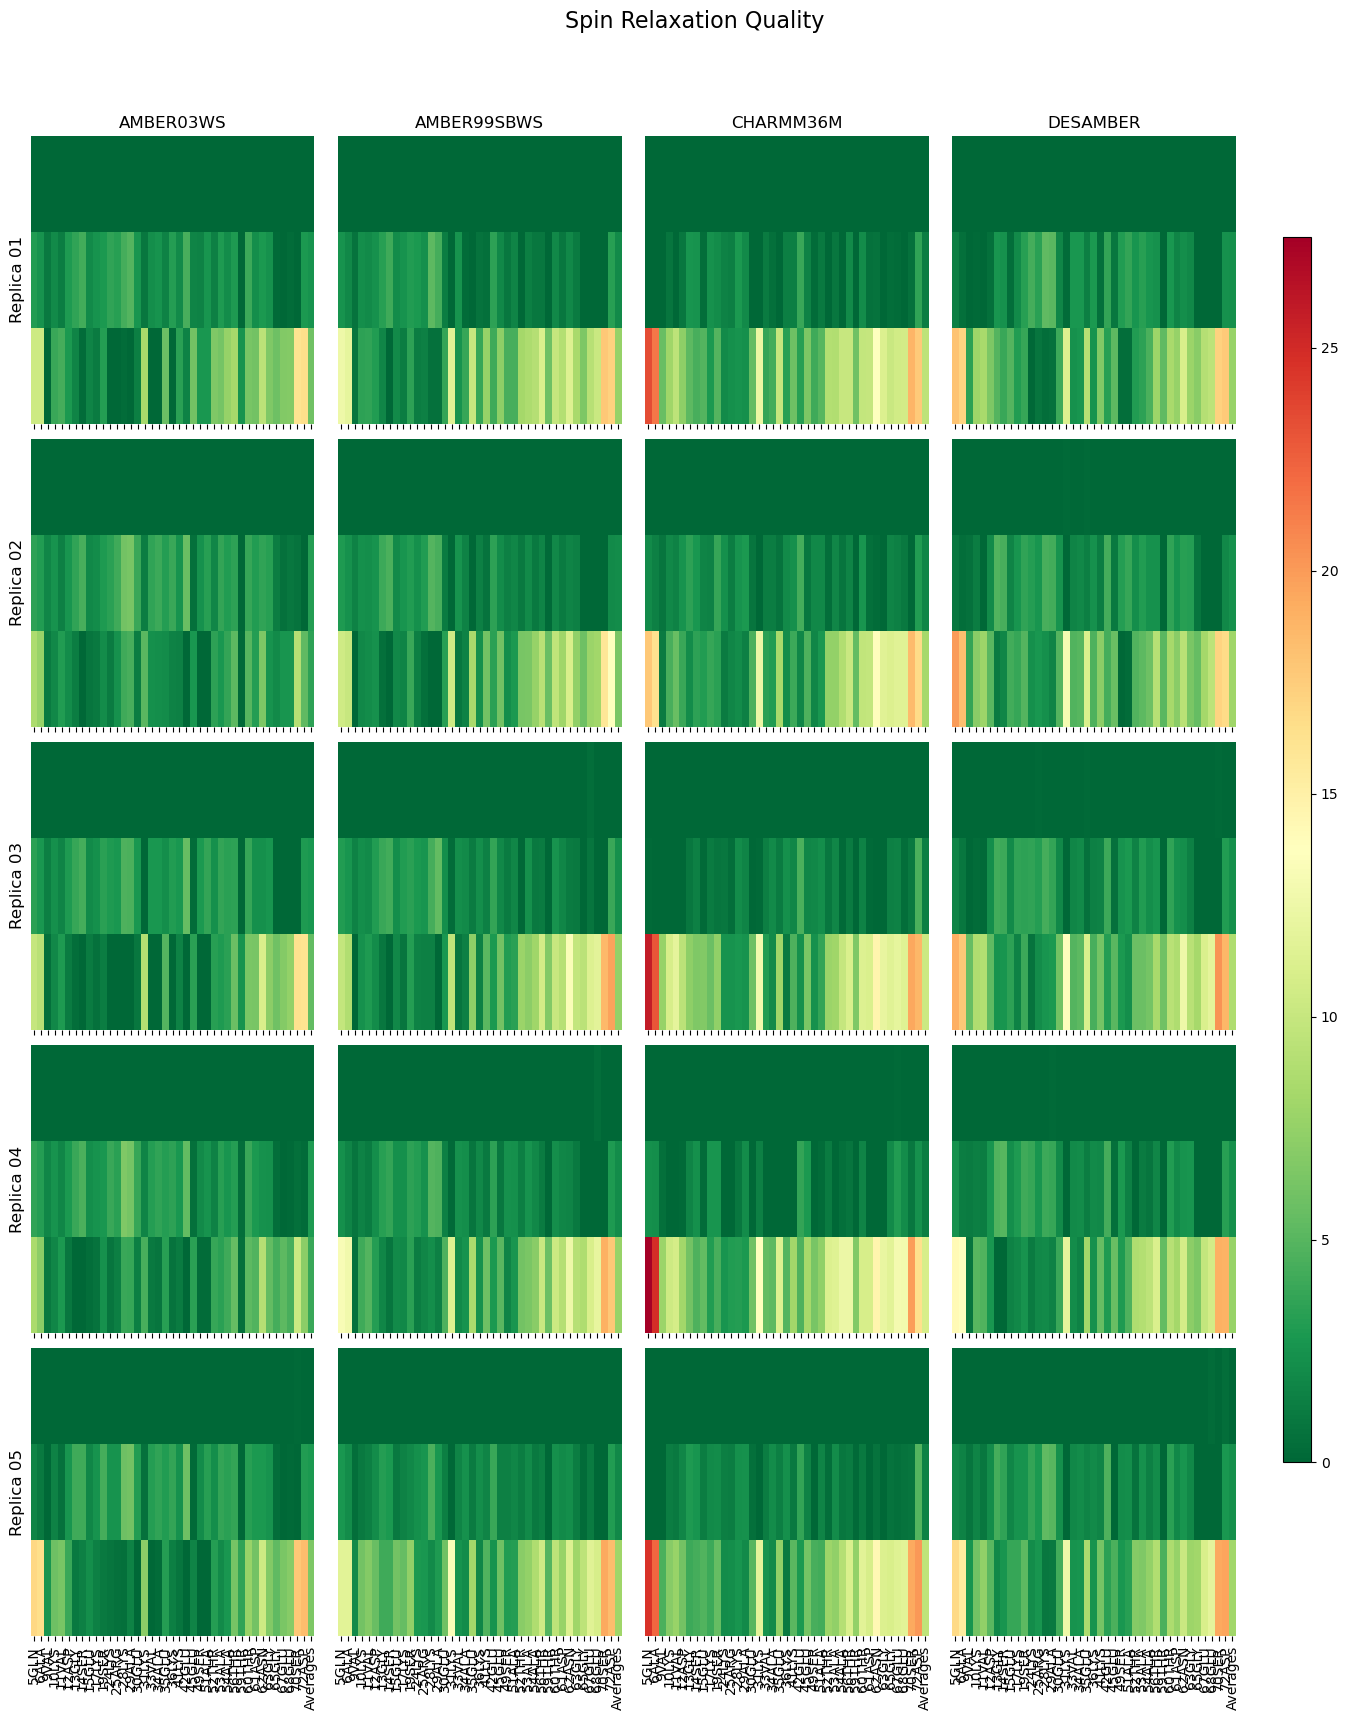

In [50]:
# Chemical shift
plot_heatmap_grid_from_csv(
    grid,
    replicas,
    forcefields,
    filename="chemical_shift_quality_heatmap.csv",
    title="Chemical Shift Quality"
)

# Relaxation
plot_heatmap_grid_from_csv(
    grid,
    replicas,
    forcefields,
    filename="spin_relaxation_quality_heatmap.csv",
    title="Spin Relaxation Quality"
)


In [17]:
for k in grid.keys():
    print(k)



03
02
04
05
01


In [18]:
for k, v in grid.items():
    print(repr(k))

'03'
'02'
'04'
'05'
'01'


In [27]:
import re

def parse_replica_forcefield(trj):
    """
    Extract replica number and forcefield from filenames like:
    - KRS1-72_replica_03_CHARMM36M_2000ns.xtc
    - aSyn_replica_04_CHARMM36M_2000ns.xtc
    - ChiZ_replica_02_AMBER03WS_2000ns.xtc
    - replica_02_DESAMBER_md_2000ns.xtc
    - replica_03_AMBER99SBWS_md_2000ns.xtc
    - replica_02_AMBER99SB-DISP_md_2000ns.xtc
    - replica_03_AMBER03WS_md_1500ns.xtc
    """

    # --- Replica ---
    rep = re.search(r"replica[_-]?(\d+)", trj)
    replica = rep.group(1) if rep else None

    # --- Force field ---
    # Captures any string between replica_<num>_ and the final _###ns
    ff = re.search(r"replica[_-]?\d+_([A-Za-z0-9\-]+?)(?:_md)?_\d+ns", trj)
    forcefield = ff.group(1) if ff else None

    return replica, forcefield


In [31]:
def build_grid(systems, base="../../Data/Simulations/"):
    grid = {}
    replicas = set()
    forcefields = set()

    for system in systems:
        trj_name = system["TRJ"][0][0]   # trajectory filename
        #print(trj_name)
        replica, ff = parse_replica_forcefield(trj_name)

        folder = base + system["path"]

        grid[(replica, ff)] = folder
        replicas.add(replica)
        forcefields.add(ff)

    replicas = sorted(replicas, key=lambda x: int(x))
    forcefields = sorted(forcefields)

    return grid, replicas, forcefields


In [32]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plot_heatmap_grid_from_csv(grid, replicas, forcefields, filename, title):
    matrices = {}
    all_values = []

    # ---- First pass: load matrices and collect values for global color scale ----
    for rep in replicas:
        for ff in forcefields:
            folder = grid[(rep, ff)]
            csvpath = os.path.join(folder, filename)

            df = pd.read_csv(csvpath, index_col=0)
            matrices[(rep, ff)] = df
            all_values.append(df.values)

    vmin = np.min(all_values)
    vmax = np.max(all_values)

    # ---- Figure ----
    n_rows = len(replicas)
    n_cols = len(forcefields)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(3*n_cols, 2.5*n_rows),
        constrained_layout=False
    )

    if n_rows == 1:
        axes = np.array([axes])
    if n_cols == 1:
        axes = axes[:, None]

    # ---- Plot each heatmap ----
    for i, rep in enumerate(replicas):
        for j, ff in enumerate(forcefields):
            ax = axes[i, j]
            df = matrices[(rep, ff)]

            sns.heatmap(
                df,
                ax=ax,
                cmap="RdYlGn_r",
                vmin=vmin,
                vmax=vmax,
                cbar=False,
                linewidths=0
            )

            # Column titles (top)
            if i == 0:
                ax.set_title(ff, fontsize=12)

            # Row labels (left)
            if j == 0:
                ax.set_ylabel(rep, fontsize=12)
            else:
                ax.set_ylabel("")

            # Bottom x-labels only
            if i == n_rows - 1:
                ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
            else:
                ax.set_xticks([])
                ax.set_xticklabels([])

            # Left y-labels only
            if j == 0:
                ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
            else:
                ax.set_yticks([])
                ax.set_yticklabels([])

    # ---- Single shared colorbar ----
    cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
    norm = plt.Normalize(vmin=vmin, vmax=vmax)
    sm = plt.cm.ScalarMappable(norm=norm, cmap="RdYlGn_r")
    fig.colorbar(sm, cax=cbar_ax)

    fig.suptitle(title, fontsize=14, y=0.97)

    plt.subplots_adjust(
        left=0.05, right=0.90,
        top=0.9, bottom=0.1,
        wspace=0.05, hspace=0.05
    )

    plt.show()


In [33]:
grid, replicas, forcefields = build_grid(systems)

plot_heatmap_grid_from_csv(
    grid,
    replicas,
    forcefields,
    filename="chemical_shift_quality_heatmap.csv",
    title="Chemical Shift Quality"
)

plot_heatmap_grid_from_csv(
    grid,
    replicas,
    forcefields,
    filename="spin_relaxation_quality_heatmap.csv",
    title="Spin Relaxation Quality"
)


TypeError: int() argument must be a string, a bytes-like object or a real number, not 'NoneType'

In [35]:
for system in systems:
    rep, ff = parse_replica_forcefield(trj)
    if rep is None or ff is None:
        print("❌ FAILED TO PARSE:", trj, "→", (rep, ff))

TypeError: expected string or bytes-like object, got 'System'

In [31]:
def read_experimental_saxs(filename):
    """
    Read experimental SAXS data file:
    Columns: q(1/nm), I(q), [error] (error optional)
    """
    q, I, err = [], [], []
    with open(filename, 'r') as f:
        for line in f:
            line = line.strip()
            # skip non-numeric lines
            if not line or not (line[0].isdigit() or line[0] == '.'):
                continue
            parts = line.split()
            try:
                q_val = float(parts[0]) / 10.0  # convert 1/nm → 1/Å
                I_val = float(parts[1])
                # optional error
                if len(parts) >= 3 and float(parts[2]) >= 0:
                    err_val = float(parts[2])
                else:
                    err_val = 0.0
                q.append(q_val)
                I.append(I_val)
                err.append(err_val)
            except ValueError:
                continue

    return np.array(q), np.array(I), np.array(err)




def read_saxs_yaml(filename):
    """Read q and I(q) data from a SAXS YAML file with flexible key names."""
    with open(filename, 'r') as f:
        data = yaml.safe_load(f)

    q, I, I_std = [], [], []
    for d in data:
        q_val = d.get('q[1/A]', d.get('q', None))
        if q_val is None:
            continue

        # Try different intensity keys
        I_key_candidates = ['mean_I(q)[a.u.]', 'mean_Inten[a.u.]', 'I(q)[a.u.]']
        I_val = None
        for key in I_key_candidates:
            if key in d:
                I_val = d[key]
                break
        if I_val is None:
            continue

        # Optional std deviation
        sd_val = d.get('sd_I(q)[a.u.]', d.get('sd_Inten[a.u.]', 0.0))
        q.append(q_val)
        I.append(I_val)
        I_std.append(sd_val)

    return np.array(q), np.array(I), np.array(I_std)

def align_experimental_to_sim(q_sim, I_sim, q_exp, I_exp):
    """Compute scaling + offset for experimental intensities."""
    # Find overlapping q-range
    q_min, q_max = max(q_sim.min(), q_exp.min()), min(q_sim.max(), q_exp.max())
    mask_sim = (q_sim >= q_min) & (q_sim <= q_max)
    mask_exp = (q_exp >= q_min) & (q_exp <= q_max)

    if np.sum(mask_sim) < 3 or np.sum(mask_exp) < 3:
        return I_exp, 1.0, 0.0  # not enough overlap

    # Interpolate experimental intensities onto simulation q-grid
    I_exp_interp = np.interp(q_sim[mask_sim], q_exp[mask_exp], I_exp[mask_exp])

    # Compute optimal scaling and offset
    # Solve least-squares fit: I_sim ≈ scale * I_exp + offset
    A = np.vstack([I_exp_interp, np.ones_like(I_exp_interp)]).T
    scale, offset = np.linalg.lstsq(A, I_sim[mask_sim], rcond=None)[0]

    I_exp_aligned = I_exp * scale + offset
    return I_exp_aligned, scale, offset


def plot_saxs_comparison(saxs_file, maicos_file, experimental_files=None):
    """Compare SAXS (simulation), MAICoS, and experimental SAXS data."""
    q_saxs, I_saxs, I_std = read_saxs_yaml(saxs_file)
    q_maicos, I_maicos, _ = read_saxs_yaml(maicos_file)
    
    # Normalize MAICoS for shape comparison
    scale_maicos = np.max(I_saxs) / np.max(I_maicos) if np.max(I_maicos) > 0 else 1.0
    I_maicos_scaled = I_maicos * scale_maicos

    plt.figure(figsize=(7, 5))
    plt.errorbar(q_saxs, I_saxs, yerr=I_std, fmt='o-', label='SAXS (simulation)', alpha=0.8)
    plt.plot(q_maicos, I_maicos_scaled, 's--', label='SAXS (MAICoS, scaled)', alpha=0.8)

    # Plot experimental data files
    if experimental_files:
        for exp_file in experimental_files:
            q_exp, I_exp, err_exp = read_experimental_saxs(exp_file)
            I_exp_aligned, scale, offset = align_experimental_to_sim(q_saxs, I_saxs, q_exp, I_exp)
            label = f"Experimental ({exp_file.split('/')[-1]}) [scale={scale:.2g}, offset={offset:.2g}]"

            if np.any(err_exp > 0):
                plt.errorbar(q_exp, I_exp_aligned, yerr=err_exp * scale, fmt='.-', label=label, alpha=0.7)
            else:
                plt.plot(q_exp, I_exp_aligned, '.-', label=label, alpha=0.7)

            print(f"{exp_file}: scale={scale:.3g}, offset={offset:.3g}")

    plt.yscale('log')
    plt.xlabel(r"$q$ (1/Å)")
    plt.ylabel(r"$I(q)$ (a.u.)")
    plt.title("SAXS Comparison: Simulation vs MAICoS vs Experimental")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


In [40]:
def align_experimental_to_sim(q_sim, I_sim, q_exp, I_exp, sigma_exp=None):
    """
    Align experimental SAXS curve to simulated curve by fitting:
        I_sim ≈ scale * I_exp + offset

    Automatically handles presence/absence of experimental errors.
    Returns:
        I_exp_aligned, scale, offset, chi2, chi2_red, rmsd
    """
    # --- Identify overlapping q-range ---
    q_min, q_max = max(q_sim.min(), q_exp.min()), min(q_sim.max(), q_exp.max())
    mask_sim = (q_sim >= q_min) & (q_sim <= q_max)
    mask_exp = (q_exp >= q_min) & (q_exp <= q_max)

    if np.sum(mask_sim) < 3 or np.sum(mask_exp) < 3:
        return I_exp, 1.0, 0.0, np.nan, np.nan, np.nan

    # --- Interpolate experimental intensity onto the simulation grid ---
    I_exp_interp = np.interp(q_sim[mask_sim], q_exp[mask_exp], I_exp[mask_exp])

    # --- AUTO-DETECT presence of experimental errors ---
    has_errors = (
        sigma_exp is not None
        and len(sigma_exp) == len(I_exp)
        and np.any(np.array(sigma_exp)[mask_exp] > 0)
    )

    if has_errors:
        sigma_interp = np.interp(q_sim[mask_sim], q_exp[mask_exp], sigma_exp[mask_exp])
        sigma_interp = np.maximum(sigma_interp, 1e-12)  # avoid divide-by-zero
        w = 1.0 / sigma_interp**2
    else:
        w = np.ones_like(I_exp_interp)

    # --- Weighted linear least squares (scale + offset) ---
    A = np.vstack([I_exp_interp, np.ones_like(I_exp_interp)]).T

    # Solve (Aᵀ W A) x = Aᵀ W I_sim
    Aw = A * w[:, None]
    scale, offset = np.linalg.lstsq(Aw.T @ A, Aw.T @ I_sim[mask_sim], rcond=None)[0]

    # --- Apply alignment to full original exp curve ---
    I_exp_aligned = I_exp * scale + offset

    # --- Compute quality metrics on overlapping region ---
    model = scale * I_exp_interp + offset
    residuals = I_sim[mask_sim] - model

    chi2 = np.sum(w * residuals**2)
    dof = max(len(residuals) - 2, 1)
    chi2_red = chi2 / dof

    rmsd = np.sqrt(np.mean(residuals**2))

    return I_exp_aligned, scale, offset, chi2, chi2_red, rmsd


In [82]:
def align_experimental_to_sim(q_sim, I_sim, q_exp, I_exp, sigma_exp=None):
    """
    Align experimental SAXS curve to simulated curve by fitting:
        I_sim ≈ scale * I_exp + offset

    Automatically handles presence/absence of experimental errors.
    Returns:
        I_exp_aligned, scale, offset, chi2, chi2_red, rmsd, rmsre
    """
    # --- Identify overlapping q-range ---
    q_min, q_max = max(q_sim.min(), q_exp.min()), min(q_sim.max(), q_exp.max())
    mask_sim = (q_sim >= q_min) & (q_sim <= q_max)
    mask_exp = (q_exp >= q_min) & (q_exp <= q_max)

    if np.sum(mask_sim) < 3 or np.sum(mask_exp) < 3:
        return I_exp, 1.0, 0.0, np.nan, np.nan, np.nan, np.nan

    # --- Interpolate experimental intensity onto the simulation grid ---
    I_exp_interp = np.interp(q_sim[mask_sim], q_exp[mask_exp], I_exp[mask_exp])

    # --- AUTO-DETECT presence of experimental errors ---
    has_errors = (
        sigma_exp is not None
        and len(sigma_exp) == len(I_exp)
        and np.any(np.array(sigma_exp)[mask_exp] > 0)
    )

    if has_errors:
        sigma_interp = np.interp(q_sim[mask_sim], q_exp[mask_exp], sigma_exp[mask_exp])
        sigma_interp = np.maximum(sigma_interp, 1e-12)  # avoid divide-by-zero
        w = 1.0 / sigma_interp**2
    else:
        w = np.ones_like(I_exp_interp)

    # --- Weighted linear least squares (scale + offset) ---
    A = np.vstack([I_exp_interp, np.ones_like(I_exp_interp)]).T

    Aw = A * w[:, None]
    scale, offset = np.linalg.lstsq(Aw.T @ A, Aw.T @ I_sim[mask_sim], rcond=None)[0]

    # --- Apply alignment to full original exp curve ---
    I_exp_aligned = I_exp * scale + offset

    # --- Compute quality metrics on overlapping region ---
    model = scale * I_exp_interp + offset
    residuals = I_sim[mask_sim] - model

    chi2 = np.sum(w * residuals**2)
    dof = max(len(residuals) - 2, 1)
    chi2_red = chi2 / dof

    rmsd = np.sqrt(np.mean(residuals**2))

    # --- RMSRE (Root Mean Square Relative Error) ---
    I_sim_safe = np.where(I_sim[mask_sim] == 0, 1e-12, I_sim[mask_sim])
    relative_err = residuals / I_sim_safe
    rmsre = np.sqrt(np.mean(relative_err**2))

    return I_exp_aligned, scale, offset, chi2, chi2_red, rmsd, rmsre


In [99]:
def align_experimental_to_sim(q_sim, I_sim, q_exp, I_exp, sigma_exp=None):
    """
    Align experimental SAXS curve to simulated curve by fitting:
        I_sim ≈ scale * I_exp + offset

    Automatically handles presence/absence of experimental errors.
    Returns:
        I_exp_aligned, scale, offset, chi2, chi2_red, rmsd, rmsre
    """
    # --- Identify overlapping q-range ---
    q_min, q_max = max(q_sim.min(), q_exp.min()), min(q_sim.max(), q_exp.max())
    mask_sim = (q_sim >= q_min) & (q_sim <= q_max)
    mask_exp = (q_exp >= q_min) & (q_exp <= q_max)

    if np.sum(mask_sim) < 3 or np.sum(mask_exp) < 3:
        return I_exp, 1.0, 0.0, np.nan, np.nan, np.nan, np.nan

    # --- Interpolate experimental intensity onto simulation grid ---
    I_exp_interp = np.interp(q_sim[mask_sim], q_exp[mask_exp], I_exp[mask_exp])

    # --- AUTO-DETECT presence of experimental errors ---
    has_errors = (
        sigma_exp is not None
        and len(sigma_exp) == len(I_exp)
        and np.any(np.array(sigma_exp)[mask_exp] > 0)
    )

    if has_errors:
        sigma_interp = np.interp(q_sim[mask_sim], q_exp[mask_exp], sigma_exp[mask_exp])
        sigma_interp = np.maximum(sigma_interp, 1e-12)
        w = 1.0 / sigma_interp**2
    else:
        w = np.ones_like(I_exp_interp)

    # --- Weighted linear least squares (scale + offset) ---
    A = np.vstack([I_exp_interp, np.ones_like(I_exp_interp)]).T
    Aw = A * w[:, None]
    scale, offset = np.linalg.lstsq(Aw.T @ A, Aw.T @ I_sim[mask_sim], rcond=None)[0]

    # --- Apply alignment to full original experimental curve ---
    I_exp_aligned = I_exp * scale + offset

    # --- Compute metrics on overlapping region ---
    model = scale * I_exp_interp + offset
    residuals = I_sim[mask_sim] - model

    chi2 = np.sum(w * residuals**2)
    dof = max(len(residuals) - 2, 1)
    chi2_red = chi2 / dof
    rmsd = np.sqrt(np.mean(residuals**2))

    # --- Relative metric without logs, robust against zeros ---
    eps = 1e-12
    denom = np.abs(I_sim[mask_sim]) + eps
    rmsre = np.sqrt(np.mean((residuals / denom)**2))

    return I_exp_aligned, scale, offset, chi2, chi2_red, rmsd, rmsre


In [41]:
def plot_saxs_comparison(saxs_file, maicos_file=None, experimental_files=None):
    """Compare SAXS (simulation), optional MAICoS, and experimental SAXS data."""
    q_saxs, I_saxs, I_std = read_saxs_yaml(saxs_file)

    # --- Optional MAICoS data ---
    if maicos_file is not None:
        q_maicos, I_maicos, _ = read_saxs_yaml(maicos_file)

        # Normalize MAICoS for shape comparison
        scale_maicos = np.max(I_saxs) / np.max(I_maicos) if np.max(I_maicos) > 0 else 1.0
        I_maicos_scaled = I_maicos * scale_maicos
    else:
        q_maicos = I_maicos_scaled = None

    # --- Plotting ---
    plt.figure(figsize=(7, 5))

    # Simulation SAXS
    plt.errorbar(q_saxs, I_saxs, yerr=I_std, fmt='o-', label='SAXS (simulation)', alpha=0.8)

    # MAICoS (only if provided)
    if maicos_file is not None:
        plt.plot(q_maicos, I_maicos_scaled, 's--', label='SAXS (MAICoS, scaled)', alpha=0.8)

    # Experimental SAXS
    if experimental_files:
        for exp_file in experimental_files:
            q_exp, I_exp, err_exp = read_experimental_saxs(exp_file)
            I_exp_aligned, scale, offset = align_experimental_to_sim(q_saxs, I_saxs, q_exp, I_exp)

            label = f"Experimental ({exp_file.split('/')[-1]}) [scale={scale:.2g}, offset={offset:.2g}]"

            if np.any(err_exp > 0):
                plt.errorbar(q_exp, I_exp_aligned, yerr=err_exp * scale, fmt='.-', label=label, alpha=0.7)
            else:
                plt.plot(q_exp, I_exp_aligned, '.-', label=label, alpha=0.7)

            print(f"{exp_file}: scale={scale:.3g}, offset={offset:.3g}")

    # --- Final plot formatting ---
    plt.yscale('log')
    plt.xlabel(r"$q$ (1/Å)")
    plt.ylabel(r"$I(q)$ (a.u.)")
    title = "SAXS Comparison: Simulation"
    if maicos_file is not None:
        title += " vs MAICoS"
    if experimental_files:
        title += " vs Experimental"
    plt.title(title)

    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


In [103]:
def plot_saxs_comparison(saxs_file, maicos_file=None, experimental_files=None, ax=None):
    """Compare SAXS (simulation), optional MAICoS, and experimental SAXS data.
       If ax is provided, plot into that axis instead of creating a new figure.
    """

    q_saxs, I_saxs, I_std = read_saxs_yaml(saxs_file)

    # Experimental data
    if experimental_files:
        for exp_file in experimental_files:
            q_exp, I_exp, err_exp = read_experimental_saxs(exp_file)
            I_exp_aligned, scale, offset, chi2, chi2_red, rmsd, rmse  = align_experimental_to_sim(q_saxs, I_saxs, q_exp, I_exp, err_exp)
            name = exp_file.split("/")[-2]

            #print(name, q_saxs, I_saxs, q_exp, I_exp, err_exp)

            label_text = name + " " + str(round(rmse,1)) #format(rmse, ".2g") + format(chi2, ".2g") + " " + format(chi2_red, ".2g") + " " + format(rmsd, ".2g")
            if np.any(err_exp > 0):
                ax.errorbar(q_exp, I_exp_aligned, yerr=err_exp * scale, fmt='.-', alpha=0.7,label=label_text)
            else:
                ax.plot(q_exp, I_exp_aligned, '.-', alpha=0.7,label=name)

    
    # Optional MAICoS
    if maicos_file is not None:
        q_maicos, I_maicos, _ = read_saxs_yaml(maicos_file)
        scale_maicos = np.max(I_saxs) / np.max(I_maicos) if np.max(I_maicos) > 0 else 1.0
        I_maicos_scaled = I_maicos * scale_maicos
    else:
        q_maicos = I_maicos_scaled = None

    # Create axis if needed
    if ax is None:
        ax = plt.gca()

    # Simulation SAXS
    ax.errorbar(q_saxs, I_saxs, yerr=I_std, fmt='o-', label='Sim', alpha=0.8)

    # MAICoS
    if maicos_file is not None:
        ax.plot(q_maicos, I_maicos_scaled, 's--', label='MAICoS', alpha=0.8)


    #ax.set_yscale('log')
    ax.set_xlabel(r"$q$ (1/Å)")
    ax.set_ylabel(r"$I(q)$ (a.u.)")
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend()

    return ax


In [19]:
protein_system = 'syn_salt'

for system in systems:
    if protein_system not in system['SYSTEM']:
        continue
        
    SAXS_file = databankPath + 'Data/Simulations/' + system['path'] + 'SAXS.yaml'
    #SAXS_MAICOS_file = databankPath + 'Data/Simulations/' + system['path'] + 'SAXS_MAICoS.yaml'
    if os.path.exists(SAXS_file):# and os.path.exists(SAXS_MAICOS_file):
        print(system['SYSTEM'], system['TRJ'], system['ID'])
        exp_files = []
        for exp_path in system['EXPERIMENT']['saxs']['path']:
            exp_file_path = databankPath + 'Data/Experiments/saxs/' + exp_path + '/saxs.dat'
            exp_files.append(exp_file_path)
        print(exp_files)
        plot_saxs_comparison(
            saxs_file=SAXS_file,
            maicos_file=None,
            experimental_files=exp_files
        )

asyn_salt [['aSyn_replica_04_CHARMM36M_2000ns.xtc']] 103
['/home/sosamuli/work/NMRlipids/IDPdatabank/Data/Experiments/saxs/SASDQK7/saxs.dat', '/home/sosamuli/work/NMRlipids/IDPdatabank/Data/Experiments/saxs/10.1038/srep30473/saxs.dat', '/home/sosamuli/work/NMRlipids/IDPdatabank/Data/Experiments/saxs/SASDQJ7/saxs.dat']


AttributeError: 'NoneType' object has no attribute 'errorbar'

In [104]:
protein_system = 'syn_salt'
grid = {}

for system in systems:
    if protein_system not in system['SYSTEM']:
        continue

    trj = system['TRJ'][0][0]

    match = re.search(r"replica_(\d+)_([A-Za-z0-9\-]+)_", trj)
    if not match:
        print("Could not parse:", trj)
        continue

    replica = match.group(1)
    forcefield = match.group(2)

    if replica not in grid:
        grid[replica] = {}

    grid[replica][forcefield] = system


In [105]:
# --- Determine sorted order of replicas and forcefields ---
replicas = sorted(grid.keys(), key=lambda x: int(x))

desired_order = [
    "AMBER03WS",
    "AMBER99SB-DISP",
    "AMBER99SBWS",
    "DESAMBER",
    "CHARMM36M",
]

forcefields = sorted(
    {ff for rep in grid.values() for ff in rep.keys()},
    key=lambda ff: desired_order.index(ff)
)

n_rows = len(replicas)
n_cols = len(forcefields)


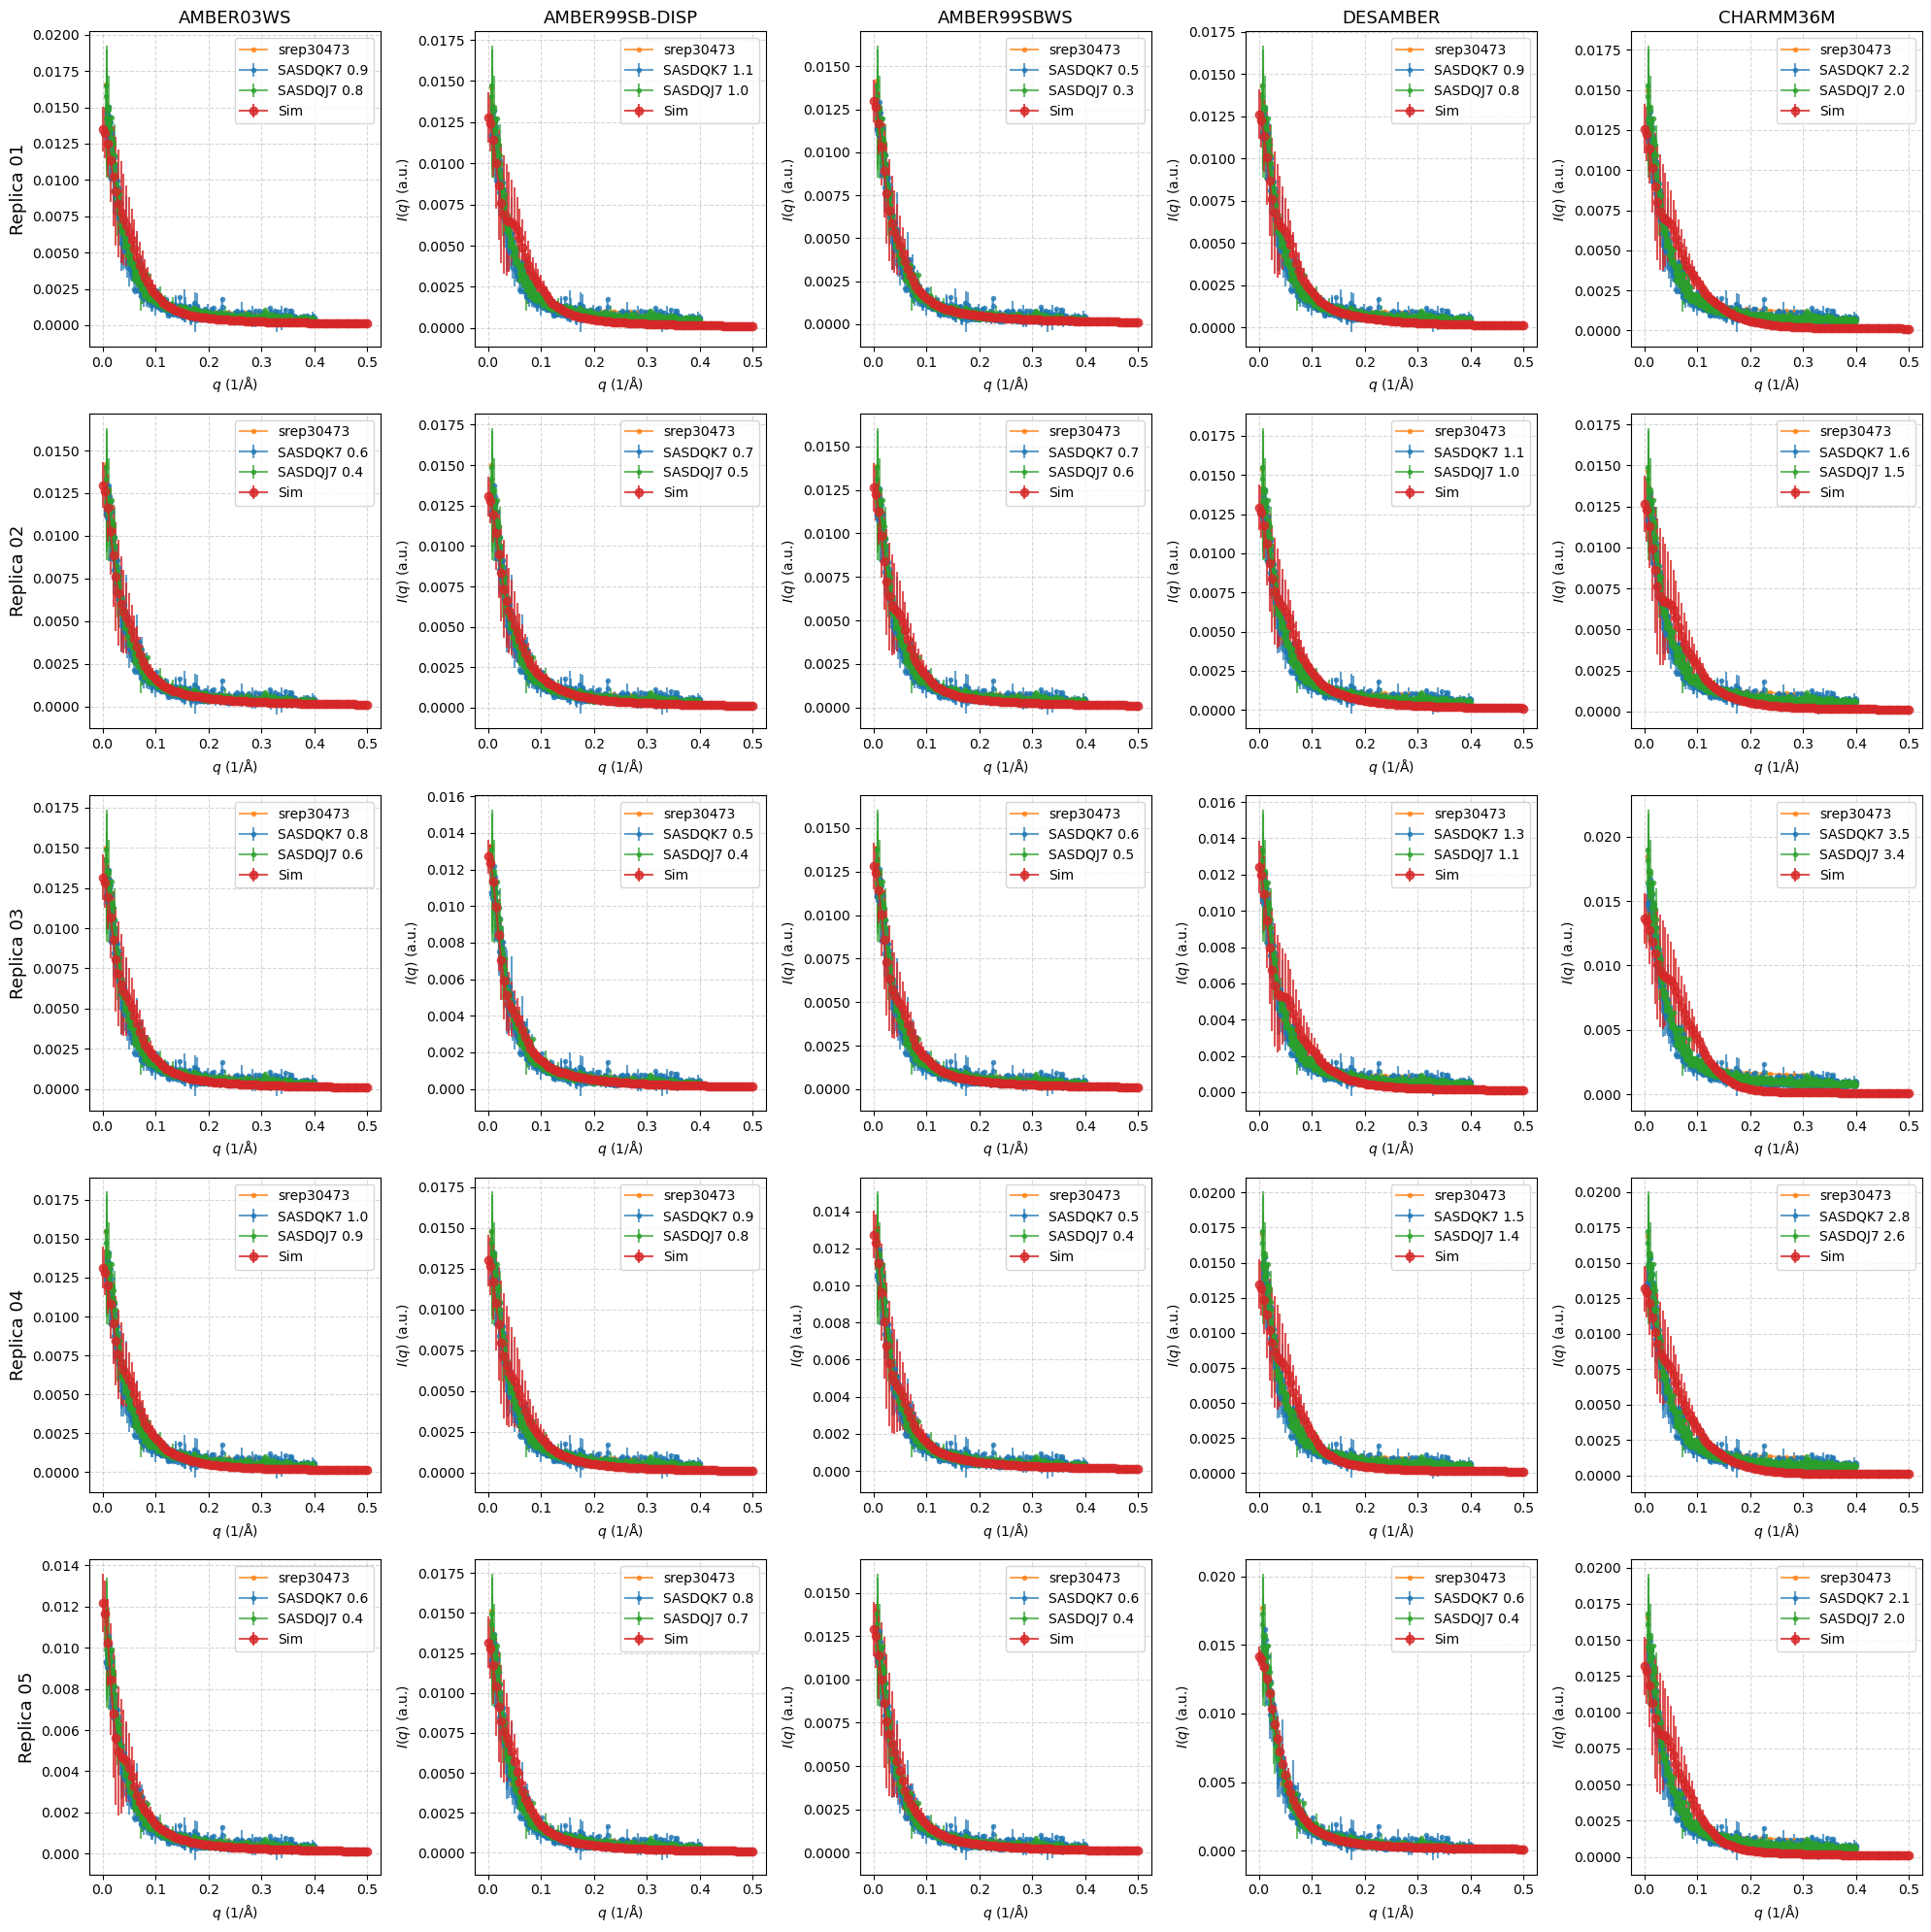

In [106]:
fig, axes = plt.subplots(
    n_rows, n_cols, 
    figsize=(4*n_cols, 4*n_rows),
    squeeze=False
)

for r_idx, replica in enumerate(replicas):
    for c_idx, forcefield in enumerate(forcefields):

        ax = axes[r_idx][c_idx]

        # If missing system, disable axis
        if forcefield not in grid[replica]:
            ax.axis("off")
            continue
        
        system = grid[replica][forcefield]

        # Paths
        SAXS_file = os.path.join(
            databankPath, "Data/Simulations", system["path"], "SAXS.yaml"
        )
        maicos_file = os.path.join(
            databankPath, "Data/Simulations", system["path"], "SAXS_MAICoS.yaml"
        )

        # Build experimental file list
        exp_files = []
        for exp_path in system["EXPERIMENT"]["saxs"]["path"]:
            exp_files.append(
                os.path.join(databankPath, "Data/Experiments/saxs", exp_path, "saxs.dat")
            )

        # Skip if simulation file missing
        if not os.path.exists(SAXS_file):
            ax.axis("off")
            continue

        # Only include MAICoS if it exists
        if not os.path.exists(maicos_file):
            maicos_file = None

        # Call your plotting function in the correct axis
        plot_saxs_comparison(
            saxs_file=SAXS_file,
            maicos_file=maicos_file,
            experimental_files=exp_files,
            ax=ax
        )

        # Titles in grid
        if r_idx == 0:
            ax.set_title(forcefield, fontsize=13)
        if c_idx == 0:
            ax.set_ylabel(f"Replica {replica}", fontsize=13)

plt.tight_layout()
plt.show()


In [116]:
for system in systems:
    if system['SYSTEM'] == 'icl2' and system['TRJ'][0][0] == 'replica_02_AMBER99SBWS_md_2000ns.xtc':
        print(system['TRJ'], system['SYSTEM'])

[['replica_02_AMBER99SBWS_md_2000ns.xtc']] icl2
